## Here we double count due to particle and hole. We need to divide by two. But then we need to multiply by two for spin. At the end, thisis OK.

In [1]:
using LinearAlgebra
using FFTW
using Plots

In [2]:
t_start = time();

In [3]:
a = 1;

### Now define the BZ and the k-space grid
N = 1000
k_vals = range(-pi / a, stop=pi / a, length=N + 1)[1:end-1]
kx_grid = collect(k_vals)
ky_grid = collect(k_vals)

dk = 2 * pi / (N * a) # grid spacing in k-space


0.006283185307179587

In [4]:
t1 = 1.0;
t2 = 0.1;
t3 = 0.8;
t4 = 0.35;
t5 = 0.000;
t6 = 0.1;

mumu = 1.1;
deltadelta = -0.2;
mu_xz = mumu;
mu_yz = mumu;
mu_xy = mumu;

Delta_0 = t1/100;

T = Delta_0/2;

nn = 10;
omega_n_grid = range(1,nn,nn)*2 * pi * T - pi * T * ones(nn);

In [5]:
function H_xy(kx, ky)
    return -2*t3*(cos(kx) + cos(ky)) - 4*t4*cos(kx)*cos(ky) - 2*t5*(cos(2*kx) + cos(2*ky)) +deltadelta - mu_xy;
end

H_xy (generic function with 1 method)

In [6]:
function Delta(kx, ky)
    return Delta_0*2*((cos(ky) - cos(kx)));
    # return Delta_0*( kx^2 - ky^2 + 2im*kx*ky )/(kx^2 + ky^2 + 0.00001^2);
end

Delta (generic function with 1 method)

In [7]:
function H_xy_BdG(kx, ky)
    return [H_xy(kx, ky) Delta(kx, ky); Delta(kx, ky)' -H_xy(kx, ky)]
end

H_xy_BdG (generic function with 1 method)

In [8]:
## Now generate a grid of real space points
Lx = 401;
Ly = 401;

In [9]:
### Here we set the impurity positions
dist_from_center = 15;

theta_rotate = pi/6;

imp_x1 = Int(round(Lx/2 - dist_from_center*cos(theta_rotate)))
imp_y1 = Int(round(Ly/2 - dist_from_center*sin(theta_rotate)))
imp_x2 = Int(round(Lx/2 + dist_from_center*cos(theta_rotate)))
imp_y2 = Int(round(Ly/2 + dist_from_center*sin(theta_rotate)))

208

In [10]:
### Green's function calculation
function G0_k(kx, ky, omega_n)
    xi = H_xy(kx, ky)
    delta = Delta(kx, ky)
    denom = omega_n^2 - xi^2 - abs2(delta)

    return ComplexF64[
        (omega_n + xi) / denom delta / denom;
        conj(delta) / denom (omega_n - xi) / denom
    ]
end


G0_k (generic function with 1 method)

In [11]:
G0_k(1.0,1.0,0.1)

2×2 Matrix{ComplexF64}:
 0.282672+0.0im       -0.0+0.0im
     -0.0+0.0im  -0.299611+0.0im

In [12]:
### Real space Green's function calculation (FFT-accelerated)
function precompute_G0_r_fft(omega_n)
    Gk11 = Matrix{ComplexF64}(undef, N, N)
    Gk12 = Matrix{ComplexF64}(undef, N, N)
    Gk21 = Matrix{ComplexF64}(undef, N, N)
    Gk22 = Matrix{ComplexF64}(undef, N, N)

    for (ix, kxv) in enumerate(kx_grid), (iy, kyv) in enumerate(ky_grid)
        xi = H_xy(kxv, kyv)
        delta = Delta(kxv, kyv)
        denom = omega_n^2 - xi^2 - abs2(delta)

        Gk11[ix, iy] = (omega_n + xi) / denom
        Gk12[ix, iy] = delta / denom
        Gk21[ix, iy] = conj(delta) / denom
        Gk22[ix, iy] = (omega_n - xi) / denom
    end

    # ifft contributes 1/N^2; multiply by 1/a^2 so normalization is dk^2/(2pi)^2 = 1/(N^2 a^2)
    norm_factor = 1 / a^2
    return (
        norm_factor * ifft(Gk11),
        norm_factor * ifft(Gk12),
        norm_factor * ifft(Gk21),
        norm_factor * ifft(Gk22),
    )
end

function G0_r_from_fft(cache, x1, y1, x2, y2)
    dx = x1 - x2
    dy = y1 - y2
    ix = mod(dx, N) + 1
    iy = mod(dy, N) + 1

    # k-grid starts at -pi, so include phase exp(-i*pi*(dx+dy)) = (-1)^(dx+dy)
    phase = isodd(dx + dy) ? -1.0 : 1.0
    G11, G12, G21, G22 = cache

    return phase .* ComplexF64[
        G11[ix, iy] G12[ix, iy];
        G21[ix, iy] G22[ix, iy]
    ]
end


G0_r_from_fft (generic function with 1 method)

In [13]:
G0_cache = precompute_G0_r_fft(0.0 + 0.0im);

In [14]:
length(G0_cache)

4

In [15]:
G0_r_from_fft(G0_cache, 1, 2, 3, 4)

2×2 Matrix{ComplexF64}:
    0.339085+3.91991e-17im  5.46265e-17-1.58101e-18im
 5.46265e-17-1.58101e-18im    -0.339085-3.91991e-17im

In [16]:
V_imp_matrix = [1 0; 0 -1]; # potential for the impurity in Nambu space

In [17]:
eps = Delta_0/100;

In [18]:
omega_n_grid

10-element Vector{Float64}:
 0.015707963267948967
 0.0471238898038469
 0.07853981633974483
 0.10995574287564278
 0.1413716694115407
 0.17278759594743864
 0.20420352248333656
 0.2356194490192345
 0.2670353755551324
 0.2984513020910303

In [19]:
LDOS = zeros(Float64, Lx, Ly)


for iii = 1:nn

    println("Processing Matsubara frequency ", iii, " / ", nn)
    omega_n_value_1 = omega_n_grid[iii];
    omega_n_value_2 = omega_n_value_1 - im*eps;

G0_cache_first = precompute_G0_r_fft(im*omega_n_value_1)
G0_cache_second = precompute_G0_r_fft(im*omega_n_value_2)

G_12_first = G0_r_from_fft(G0_cache_first, imp_x1, imp_y1, imp_x2, imp_y2)
G_21_first = G0_r_from_fft(G0_cache_first, imp_x2, imp_y2, imp_x1, imp_y1)

G_12_second = G0_r_from_fft(G0_cache_second, imp_x1, imp_y1, imp_x2, imp_y2)
G_21_second = G0_r_from_fft(G0_cache_second, imp_x2, imp_y2, imp_x1, imp_y1)

for x in 1:Lx
    for y in 1:Ly
        G_x1_first = G0_r_from_fft(G0_cache_first, x, y, imp_x1, imp_y1)
        G_2x_first = G0_r_from_fft(G0_cache_first, imp_x2, imp_y2, x, y)

        G_1x_first = G0_r_from_fft(G0_cache_first, imp_x1, imp_y1, x, y)
        G_x2_first = G0_r_from_fft(G0_cache_first, x, y, imp_x2, imp_y2)

        G_x1_second = G0_r_from_fft(G0_cache_second, x, y, imp_x1, imp_y1)
        G_2x_second = G0_r_from_fft(G0_cache_second, imp_x2, imp_y2, x, y)

        G_1x_second = G0_r_from_fft(G0_cache_second, imp_x1, imp_y1, x, y)
        G_x2_second = G0_r_from_fft(G0_cache_second, x, y, imp_x2, imp_y2)

        value = 0*im;

        value -= tr(G_x1_first * V_imp_matrix * G_12_first * V_imp_matrix * G_2x_first)
        value -= tr(G_x2_first * V_imp_matrix * G_21_first * V_imp_matrix * G_1x_first)
        value += tr(G_x1_second * V_imp_matrix * G_12_second * V_imp_matrix * G_2x_second)
        value += tr(G_x2_second * V_imp_matrix * G_21_second * V_imp_matrix * G_1x_second)

        val = value/eps;
        
        LDOS[x, y] += T*real(val);
    end
end

end

Processing Matsubara frequency 1 / 10
Processing Matsubara frequency 2 / 10
Processing Matsubara frequency 3 / 10
Processing Matsubara frequency 4 / 10
Processing Matsubara frequency 5 / 10
Processing Matsubara frequency 6 / 10
Processing Matsubara frequency 7 / 10
Processing Matsubara frequency 8 / 10
Processing Matsubara frequency 9 / 10
Processing Matsubara frequency 10 / 10


In [20]:
## Set the values at the two impurities zero
LDOS[imp_x1, imp_y1] = 0.0;
LDOS[imp_x2, imp_y2] = 0.0;

In [21]:
custom_cmap = cgrad([:blue, :white, :orange], [0.4, 0.6])

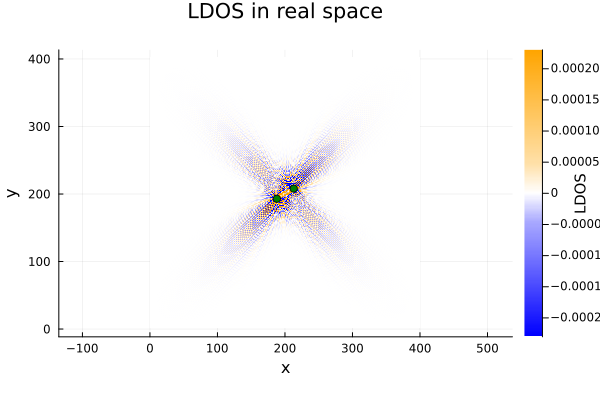

In [22]:
### Now we plot the LDOS in real space (zoomed around center)
clip = maximum(abs.(LDOS))/10;
heatmap(LDOS', xlabel="x", ylabel="y", title="LDOS in real space", colorbar_title="LDOS", c=custom_cmap, aspect_ratio=1, clim=(-clip, clip))
scatter!([imp_x1, imp_x2], [imp_y1, imp_y2], markersize=4, markerstrokewidth=1, color=:green, label="Impurities", legend=false)

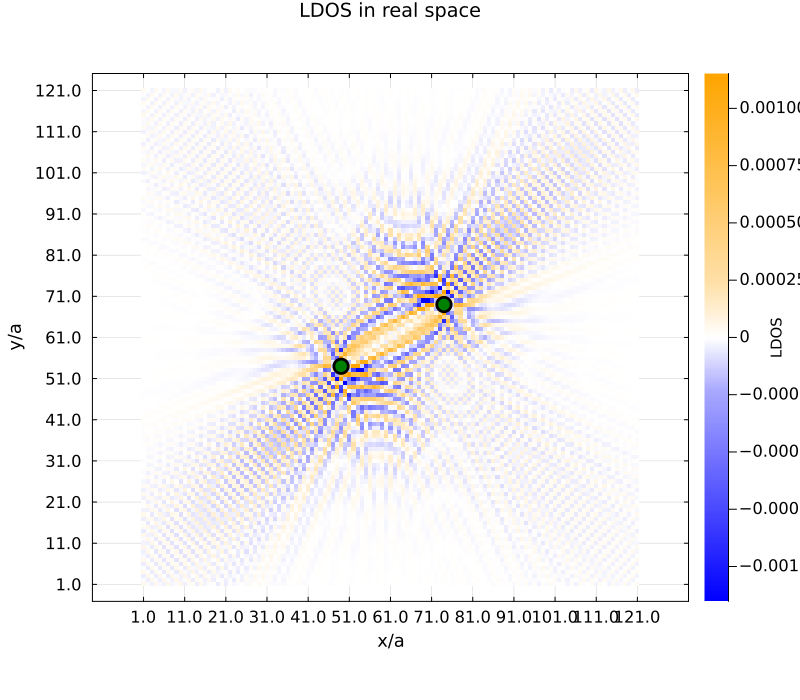

In [23]:
### Publication quality plot: LDOS in real space (zoomed around center) with x/a and y/a axes
xrange = (Int(round(Lx / 2)) - 60):(Int(round(Lx / 2)) + 60)
yrange = (Int(round(Ly / 2)) - 60):(Int(round(Ly / 2)) + 60)

# Convert to normalized coordinates (x/a, y/a)
x_coords = (collect(xrange) .- 1) ./ a
y_coords = (collect(yrange) .- 1) ./ a

# Relabel x-axis from 1 to (max - min)
x_shift = minimum(x_coords)
x_labels = x_coords .- x_shift .+ 1

idx = 1:10:length(x_coords)  # keep every 10th tick
xt = (x_coords[idx], round.(x_labels[idx]; digits=1))

clip = maximum(abs.(LDOS[xrange, yrange]))/2

p = heatmap(x_coords, y_coords, LDOS[xrange, yrange]', 
    xlabel="x/a", ylabel="y/a", 
    title="LDOS in real space",
    colorbar_title="LDOS", 
    c=custom_cmap, 
    aspect_ratio=1, 
    clim=(-clip, clip),
    framestyle=:box,
    legend=false,
    size=(800, 700),
    margin=2Plots.mm,
    tickfontsize=11,
    guidefontsize=12,
    titlefontsize=13,
    colorbar=:right,
    xticks=xt,
    yticks=xt
)

# Add impurity positions (convert from 1-based index to physical coordinates)
scatter!([(imp_x1 - 1) ./ a, (imp_x2 - 1) ./ a], 
         [(imp_y1 - 1) ./ a, (imp_y2 - 1) ./ a],
    markersize=8, markerstrokewidth=2, color=:green,
    label="Impurities", legend=false
)

p

In [24]:
LDOS_interesting = LDOS[xrange, yrange];

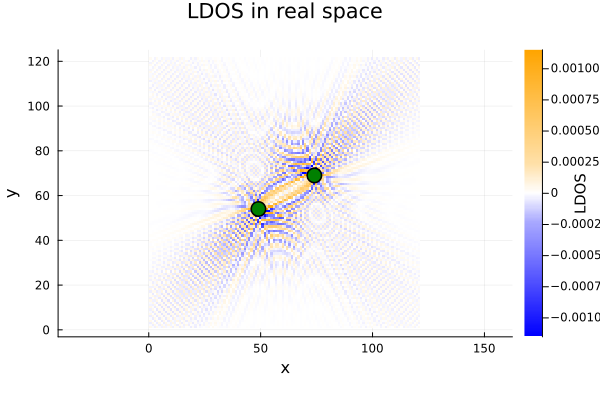

In [26]:
### Now we plot the LDOS in real space (zoomed around center)
xrange = (Int(round(Lx / 2)) - 60):(Int(round(Lx / 2)) + 60)
yrange = (Int(round(Ly / 2)) - 60):(Int(round(Ly / 2)) + 60)
clip = maximum(abs.(LDOS[xrange, yrange]))/2;
heatmap(LDOS[xrange, yrange]', xlabel="x", ylabel="y", title="LDOS in real space", colorbar_title="LDOS", c=custom_cmap, aspect_ratio=1, clim=(-clip, clip))
scatter!([imp_x1 - xrange[1] + 1, imp_x2 - xrange[1] + 1], [imp_y1 - yrange[1] + 1, imp_y2 - yrange[1] + 1],
    markersize=8, markerstrokewidth=2, color=:green,
    label="Impurities", legend=false
)

In [27]:
t_stop = time();
println("Time taken: ", t_stop - t_start, " seconds")

Time taken: 75.45072102546692 seconds


In [ ]:
using DelimitedFiles
writedlm("LDOS_cuprate_xy_julia_code_strontium_ruthenate_BdG.csv", LDOS, ',')